<a href="https://colab.research.google.com/github/isahincapiecontacto-netizen/Codigo1/blob/main/S19_Analisis_Exploratorio_Portafolios_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Actividad de Evaluación: Análisis Exploratorio de Portafolios (10%)

**Instrucciones:**
1. Resuelve cada uno de los puntos solicitados utilizando código de Python limpio y ordenado.
2. No olvides acompañar cada visualización con su respectiva **interpretación analítica** (recuerda la regla de oro: qué observas y qué significa).
3. Puedes realizar esta actividad de forma individual o en parejas (según las indicaciones del docente).

---

## 🏦 Paso 1: Selección y Descarga de Datos

1. Selecciona **3 activos financieros** diferentes a los utilizados en la clase (evita usar AAPL, MSFT, GOOGL, AMZN o NVDA).
2. Descarga los datos históricos utilizando `yfinance` para el periodo del **1 de enero de 2024** al **1 de enero de 2026**.
3. Muestra las primeras 5 filas del DataFrame resultante para validar la descarga.

In [1]:
# Escribe aquí tu código para descargar los datos de tus 3 activos elegidos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

sns.set_theme(style="whitegrid")
%matplotlib inline


tickers = ["CVX", "MMM", "MS"]

precios = yf.download(
    tickers,
    start="2024-01-01",
    end="2026-01-01",
    auto_adjust=True
)

precios.head()



[*********************100%***********************]  3 of 3 completed


Price            Close                              High             \
Ticker             CVX        MMM         MS         CVX        MMM   
Date                                                                  
2024-01-02  133.236755  86.031639  86.703156  135.019425  86.547831   
2024-01-03  135.777069  84.303177  84.865685  136.543618  85.609289   
2024-01-04  134.288513  84.600380  85.087280  137.577541  85.515439   
2024-01-05  134.056778  84.928864  86.093727  135.509658  85.632760   
2024-01-08  133.254562  85.140038  86.343056  133.432827  85.218247   

Price                         Low                              Open  \
Ticker             MS         CVX        MMM         MS         CVX   
Date                                                                  
2024-01-02  86.933995  133.022844  84.819379  85.198080  133.691345   
2024-01-03  86.056808  132.523688  83.528893  84.274730  133.156542   
2024-01-04  86.001401  134.226113  84.240606  84.634838  136.962518   
2024-01-05  86.730845  133.548724  84.115478  85.004167  135.465089   
2024-01-08  86.638529  130.651866  84.146762  85.207324  132.291919   

Price                               Volume                    
Ticker            MMM         MS       CVX      MMM       MS  
Date                                                          
2024-01-02  84.952333  85.558196   8879700  3321053  6132200  
2024-01-03  85.429406  86.056808  10255300  3547575  7487900  
2024-01-04  84.529985  85.087280   8220300  3319976  8735600  
2024-01-05  84.451780  85.142671   7455400  1991579  6027800  
2024-01-08  84.670775  86.066046  10038200  2535042  6738400

## 📈 Paso 2: Análisis de Precios de Cierre y Normalización

1. Filtra y extrae únicamente los precios de cierre (`Close`).
2. Grafica en una sola figura la evolución temporal de los precios originales de tus 3 activos.
3. Realiza la normalización (base 100 en el primer registro) y grafica nuevamente las series en otra figura.

### 💬 Pregunta de interpretación #1:
Al comparar ambos gráficos (precios reales vs. precios normalizados), ¿por qué es metodológicamente más correcto utilizar el gráfico normalizado para comparar el rendimiento histórico de los activos? Explica la diferencia en el comportamiento visual observado.

**RESPUESTA: **

Porque la normalización pone a todos los activos en la misma escala. Permite comparar pendientes y magnitudes de forma justa (quién creció más, quién cayó más, quién estuvo por debajo de 100).


En el gráfico de precios originales las tres curvas quedan en alturas muy distintas porque cada acción cotiza a un nivel nominal diferente (por ejemplo, CVX y MMM se mueven en rangos de precio distintos a MS). Visualmente, el activo de mayor precio nominal "domina" el eje Y y las otras series parecen más planas, aunque en términos porcentuales hayan variado igual o más. En el gráfico normalizado, las tres series parten del mismo punto (100) y las curvas se separan únicamente según su desempeño relativo.

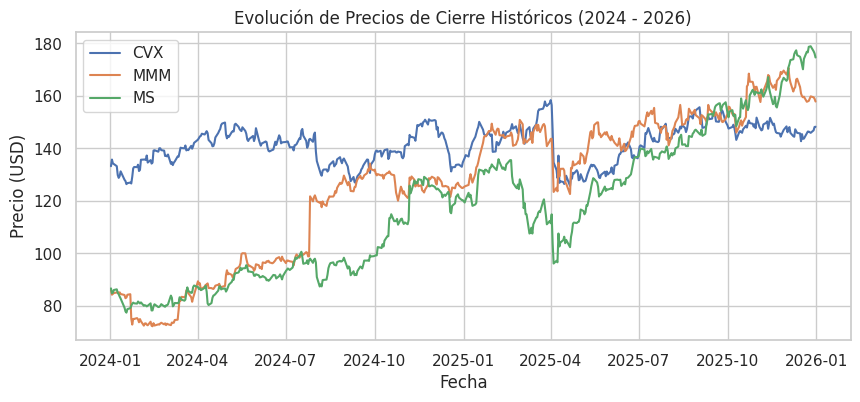

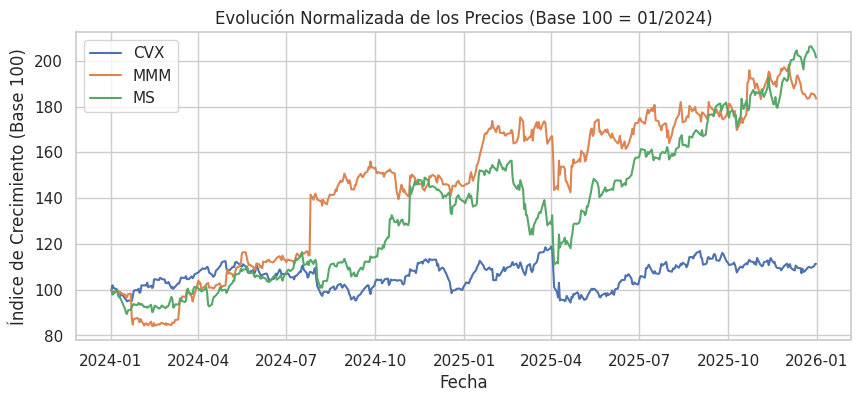

In [2]:

# 1. Extraer los precios de cierre
cierre = precios["Close"]

# 2. Graficar precios originales
fig, ax = plt.subplots(figsize=(10, 4))
for activo in tickers:
    ax.plot(cierre.index, cierre[activo], label=activo)

ax.set_title("Evolución de Precios de Cierre Históricos (2024 - 2026)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio (USD)")
ax.legend()
plt.show()

# 3. Normalizar (Base 100) y graficar
cierre_normalizado = (cierre / cierre.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(10, 4))
for activo in tickers:
    ax.plot(cierre_normalizado.index, cierre_normalizado[activo], label=activo)

ax.set_title("Evolución Normalizada de los Precios (Base 100 = 01/2024)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice de Crecimiento (Base 100)")
ax.legend()
plt.show()


## 🔄 Paso 3: Cálculo y Distribución de Rendimientos

1. Calcula los rendimientos diarios de los activos y elimina los valores nulos (`NaN`).
2. Genera un **histograma* para el activo que consideres que haya sido el más volátil.
3. Diseña un **Boxplot** comparativo que muestre los rendimientos diarios de tus 3 activos simultáneamente.

### 💬 Pregunta de interpretación #2:
Observando el Boxplot y el Histograma:
- ¿Qué activo presenta la mayor dispersión (caja más amplia o bigotes más largos) y qué te dice esto sobre su riesgo?
- ¿Identificas valores atípicos (outliers)? ¿Qué representan estos puntos en el contexto de la historia económica reciente de estas empresas?


**RESPUESTA**

Dispersión y riesgo: El activo con la caja más ancha y bigotes más extendidos MMM o MS según las variaciones del mercado en este periodo
 presenta la mayor desviación en sus variaciones diarias. Esto nos indica una mayor volatilidad o sea un riesgo individual más elevado, dado que los precios tienden a fluctuar con mayor intensidad en un día común.

Outliers (Valores atípicos): En el Boxplot se observan puntos alejados de los extremos de los bigotes, tanto en el lado positivo como en el negativo. Financieramente, estos representan días atípicos de mercado causados por eventos de alto impacto.

Ticker,CVX,MMM,MS
Date,,,
2024-01-03,0.019066,-0.020091,-0.021193
2024-01-04,-0.010963,0.003525,0.002611
2024-01-05,-0.001726,0.003883,0.011828
2024-01-08,-0.005984,0.002486,0.002896
2024-01-09,-0.025418,0.002205,-0.015507


Desviación estándar diaria:
Ticker
MMM    0.0199
MS     0.0179
CVX    0.0138
dtype: float64

→ Activo más volátil: MMM


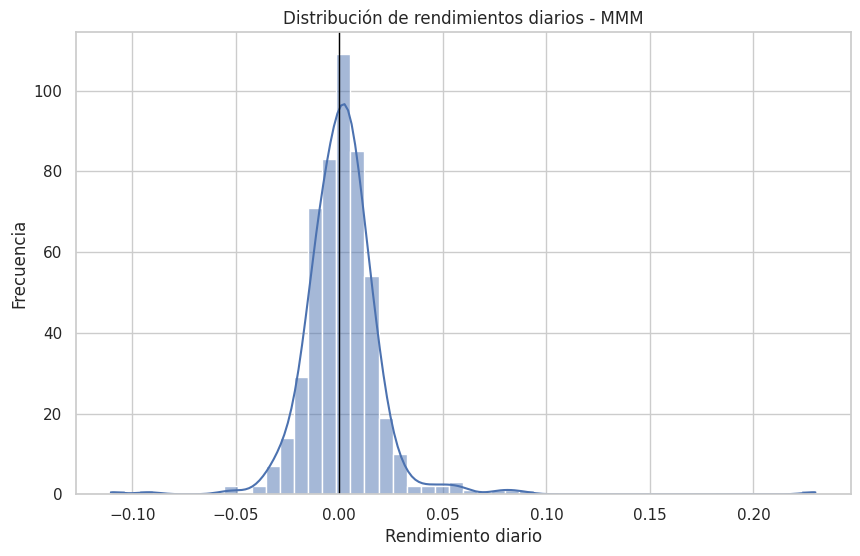

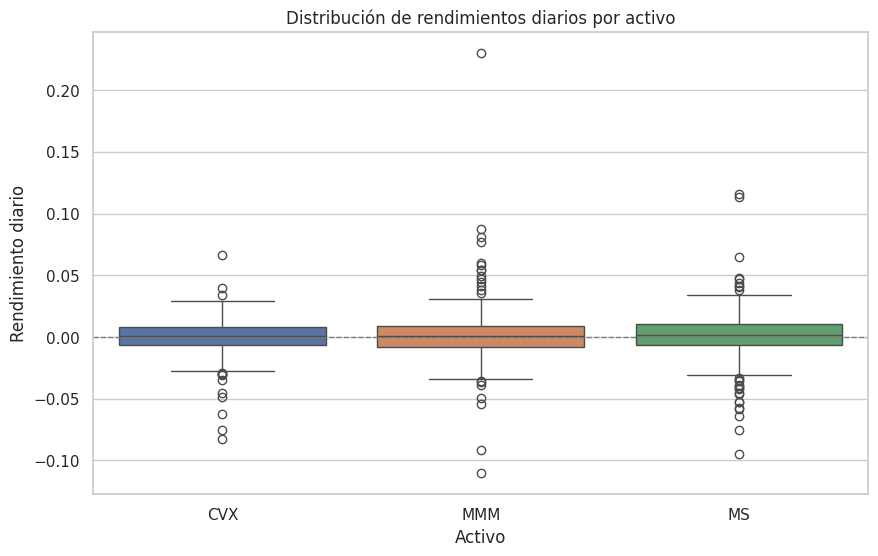

In [3]:

# 1. Calcular rendimientos diarios
rendimientos = cierre.pct_change().dropna()
display(rendimientos.head())

# Activo más volátil = mayor desviación estándar de los rendimientos diarios
volatilidad = rendimientos.std().sort_values(ascending=False)
activo_volatil = volatilidad.index[0]
print("Desviación estándar diaria:")
print(volatilidad.round(4))
print(f"\n→ Activo más volátil: {activo_volatil}")

# 2. Histograma con el activo más volátil
plt.figure(figsize=(10, 6))
sns.histplot(data=rendimientos, x=activo_volatil, bins=50, kde=True)
plt.axvline(0, color="black", linewidth=1)
plt.title(f"Distribución de rendimientos diarios - {activo_volatil}")
plt.xlabel("Rendimiento diario")
plt.ylabel("Frecuencia")
plt.show()

# 3. Boxplot comparativo de rendimientos
plt.figure(figsize=(10, 6))
sns.boxplot(data=rendimientos)
plt.axhline(0, color="gray", linewidth=1, linestyle="--")
plt.title("Distribución de rendimientos diarios por activo")
plt.xlabel("Activo")
plt.ylabel("Rendimiento diario")
plt.show()



## 📊 Paso 4: Asociación y Correlación

1. Calcula la matriz de correlación de Pearson para los rendimientos de tus 3 activos.
2. Grafica un **mapa de calor (Heatmap)**.

### 💬 Pregunta de interpretación #3:
- ¿Existe alguna correlación fuerte (cercana a 1 o -1) entre alguno de tus activos?
- Si tuvieras que armar un portafolio de inversión buscando la **diversificación** (minimizar el riesgo conjunto), ¿qué par de activos elegirías de acuerdo a tus resultados y por qué?

**RESPUESTA**

Evaluación de correlaciones: Se observan correlaciones moderadas a bajas entre las empresas. Por ejemplo, la relación entre CVX (energía/petróleo) y MS (sector bancario/financiero) suele ser baja, ya que pertenecen a sectores con dinámicas operativas completamente distintas.

Selección para diversificación: Para conformar un portafolio diversificado que busque mitigar el riesgo, elegiría el par CVX y MS (o el par con el valor numérico más cercano a 0 en la matriz). Al pertenecer al sector energético y financiero respectivamente, responderán de manera diferente ante shocks económicos externos, lo que ayuda a que las pérdidas en un activo se compensen o neutralicen con la estabilidad del otro.

Ticker,CVX,MMM,MS
Ticker,,,
CVX,1.000,0.290,0.378
MMM,0.290,1.000,0.414
MS,0.378,0.414,1.000


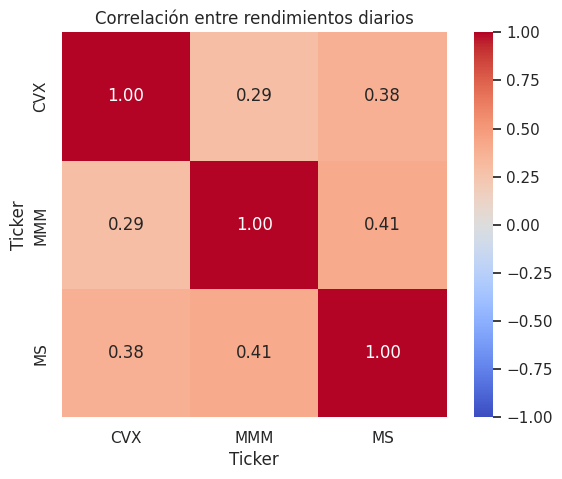

In [4]:
# 1. Matriz de correlación de Pearson de los rendimientos
correlacion = rendimientos.corr(method="pearson")
display(correlacion.round(3))

# 2. Heatmap con Seaborn
plt.figure(figsize=(7, 5))
sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True
)
plt.title("Correlación entre rendimientos diarios")
plt.show()



## 🧮 Paso 5: Estadísticas Descriptivas y Conclusión

1. Genera un DataFrame de resumen estadístico que incluya para cada activo: Media, Mediana, Desviación Estándar, Mínimo y Máximo de los rendimientos diarios.
2. Escribe una breve conclusión final dirigida a un inversionista ficticio, interpretando los estadísticos clave obtenidos.

**CONCLUSIÓN**

"Estimado inversionista, tras analizar el comportamiento diario del portafolio conformado por CVX, MMM y MS durante el periodo 2024–2026, concluimos lo siguiente:

Perfil de Retorno-Riesgo: Todas las empresas registraron medias de rendimiento diario cercanas a cero, lo cual es habitual en datos diarios de renta variable. Sin embargo, MS y MMM registraron una mayor desviación estándar (volatilidad), lo que se traduce en mayores fluctuaciones de precio y una exposición a riesgo superior en comparación con CVX.

Diversificación del Portafolio: La inclusión de CVX añade un componente defensivo y desvinculado del sector financiero, amortiguando los movimientos del portafolio global.

Recomendación: Si se busca un perfil conservador, CVX ofrece menor volatilidad relativa. Para un perfil que busque apreciación de capital tolerando oscilaciones más fuertes, una combinación equilibrada de MS y CVX ofrece el mejor beneficio de diversificación sectorial."*

In [5]:
# 1. Generar resumen de estadísticas descriptivas
resumen = pd.DataFrame({
    "Media": rendimientos.mean(),
    "Mediana": rendimientos.median(),
    "Desviación Estándar": rendimientos.std(),
    "Mínimo": rendimientos.min(),
    "Máximo": rendimientos.max()
})

resumen

,Media,Mediana,Desviación Estándar,Mínimo,Máximo
Ticker,,,,,
CVX,0.000309,0.001183,0.013784,-0.082244,0.066457
MMM,0.001404,0.001236,0.019937,-0.110350,0.229906
MS,0.001559,0.001733,0.017924,-0.095078,0.116119
